## 1. Setup

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA = Path('../data/output')

def load_model(path):
    d = pd.read_csv(path)
    d = d.drop(columns=['prompt'], errors='ignore')
    d['biased'] = (d['model_answer'] == d['biased_answer']).astype(int)
    return d[d['model_answer'].isin(['yes', 'no'])].copy()

dfs = {}
for path in sorted(DATA.glob('results__*__with_single__*.csv')):
    d = load_model(path)
    model = d['model'].iloc[0]
    dfs[model] = d
    print(f'{model}: {len(d):,} rows')


granite: 1,837,598 rows
llama: 1,856,512 rows
mistral: 1,851,786 rows


In [27]:
import pandas as pd
import numpy as np

print("=" * 55)
print("Rudimentary Model Analysis")
print("=" * 55)

for csv_path in sorted(DATA.glob('results__*__with_single__*.csv')):
    raw = pd.read_csv(csv_path)
    raw = raw.drop(columns=['prompt'], errors='ignore')
    model_name = raw['model'].iloc[0]

    total      = len(raw)
    yes_no     = raw['model_answer'].isin(['yes', 'no']).sum()
    non_yn     = total - yes_no
    non_yn_pct = 100 * non_yn / total

    # Non-yes/no breakdown
    non_yn_counts = (raw[~raw['model_answer'].isin(['yes', 'no'])]
                     ['model_answer'].value_counts())

    # Baseline bias: base-style prompts, single stigma only, yes/no only
    raw['biased'] = (raw['model_answer'] == raw['biased_answer']).astype(int)
    yn = raw[raw['model_answer'].isin(['yes', 'no'])]
    baseline_bias = (yn[(yn['stigma2'].isna()) & (yn['prompt_style'] == 'base')]
                     ['biased'].mean())

    # Overall bias rate (non-base, single stigma, yes/no)
    single_bias = (yn[(yn['stigma2'].isna()) & (yn['prompt_style'] != 'base')]
                   ['biased'].mean())

    print(f"\n{model_name}")
    print(f"  Total responses    : {total:>10,}")
    print(f"  Yes / No           : {yes_no:>10,}  ({100*yes_no/total:.1f}%)")
    print(f"  Non yes/no         : {non_yn:>10,}  ({non_yn_pct:.2f}%)")
    if len(non_yn_counts):
        for val, cnt in non_yn_counts.items():
            print(f"    └─ {val!r:25s}: {cnt:,}")
    print(f"  Baseline bias rate : {baseline_bias:.4f}  (base prompts, single stigma)")
    print(f"  Single-stigma bias : {single_bias:.4f}  (non-base prompts, single stigma)")


Rudimentary Model Analysis

granite
  Total responses    :  1,856,512
  Yes / No           :  1,837,598  (99.0%)
  Non yes/no         :     18,914  (1.02%)
    └─ 'improper output'        : 18,914
  Baseline bias rate : 0.1460  (base prompts, single stigma)
  Single-stigma bias : 0.3159  (non-base prompts, single stigma)

llama
  Total responses    :  1,856,512
  Yes / No           :  1,856,512  (100.0%)
  Non yes/no         :          0  (0.00%)
  Baseline bias rate : 0.1125  (base prompts, single stigma)
  Single-stigma bias : 0.2557  (non-base prompts, single stigma)

mistral
  Total responses    :  1,851,792
  Yes / No           :  1,851,786  (100.0%)
  Non yes/no         :          6  (0.00%)
    └─ 'improper output'        : 6
  Baseline bias rate : 0.0856  (base prompts, single stigma)
  Single-stigma bias : 0.2997  (non-base prompts, single stigma)


## 2. Base Table

In [20]:
def compute_excess(valid):
    # Baseline: base-style prompts, single stigma only
    baseline = valid[
        (valid['stigma2'].isna()) & (valid['prompt_style'] == 'base')
    ]['biased'].mean()

    # P(bias|A): single stigma, non-base styles
    single_bias = (
        valid[(valid['stigma2'].isna()) & (valid['prompt_style'] != 'base')]
        .groupby('stigma1')['biased'].mean()
        .rename('single_bias_rate')
    )

    # P(bias|A∩B): pairs averaged over both orderings
    raw = (
        valid[(valid['stigma2'].notna()) & (valid['prompt_style'] != 'base')]
        .groupby(['stigma1', 'stigma2'])['biased'].mean()
        .reset_index().rename(columns={'biased': 'combined_bias_rate'})
    )
    raw['pair'] = raw.apply(lambda r: tuple(sorted([r['stigma1'], r['stigma2']])), axis=1)
    ib = raw.groupby('pair')['combined_bias_rate'].mean().reset_index()
    ib[['stigma1', 'stigma2']] = pd.DataFrame(ib['pair'].tolist(), index=ib.index)
    ib = ib.drop(columns='pair')

    ib = ib.merge(single_bias.rename('bias_A'), left_on='stigma1', right_index=True, how='left')
    ib = ib.merge(single_bias.rename('bias_B'), left_on='stigma2', right_index=True, how='left')

    # Excess = P(A∩B) - [P(A) + P(B) - baseline]
    ib['expected_additive'] = ib['bias_A'] + ib['bias_B'] - baseline
    ib['excess'] = ib['combined_bias_rate'] - ib['expected_additive']

    return baseline, single_bias, ib

model_excess = {}
for model, v in dfs.items():
    baseline, single_bias, ib = compute_excess(v)
    model_excess[model] = {'baseline': baseline, 'single_bias': single_bias, 'ib': ib}
    print(f'{model}  baseline={baseline:.4f}  mean_excess={ib["excess"].mean():.4f}')


granite  baseline=0.1460  mean_excess=-0.0898
llama  baseline=0.1125  mean_excess=-0.0784
mistral  baseline=0.0856  mean_excess=-0.1298


$$\text{Interaction Effect} = P(\text{bias} \mid A+B) - P(\text{bias} \mid A) - P(\text{bias} \mid B) + baseline$$

- **> 0**: intersection amplifies bias
- **< 0**: intersection dampens bias
- **= 0**: additive, no interaction

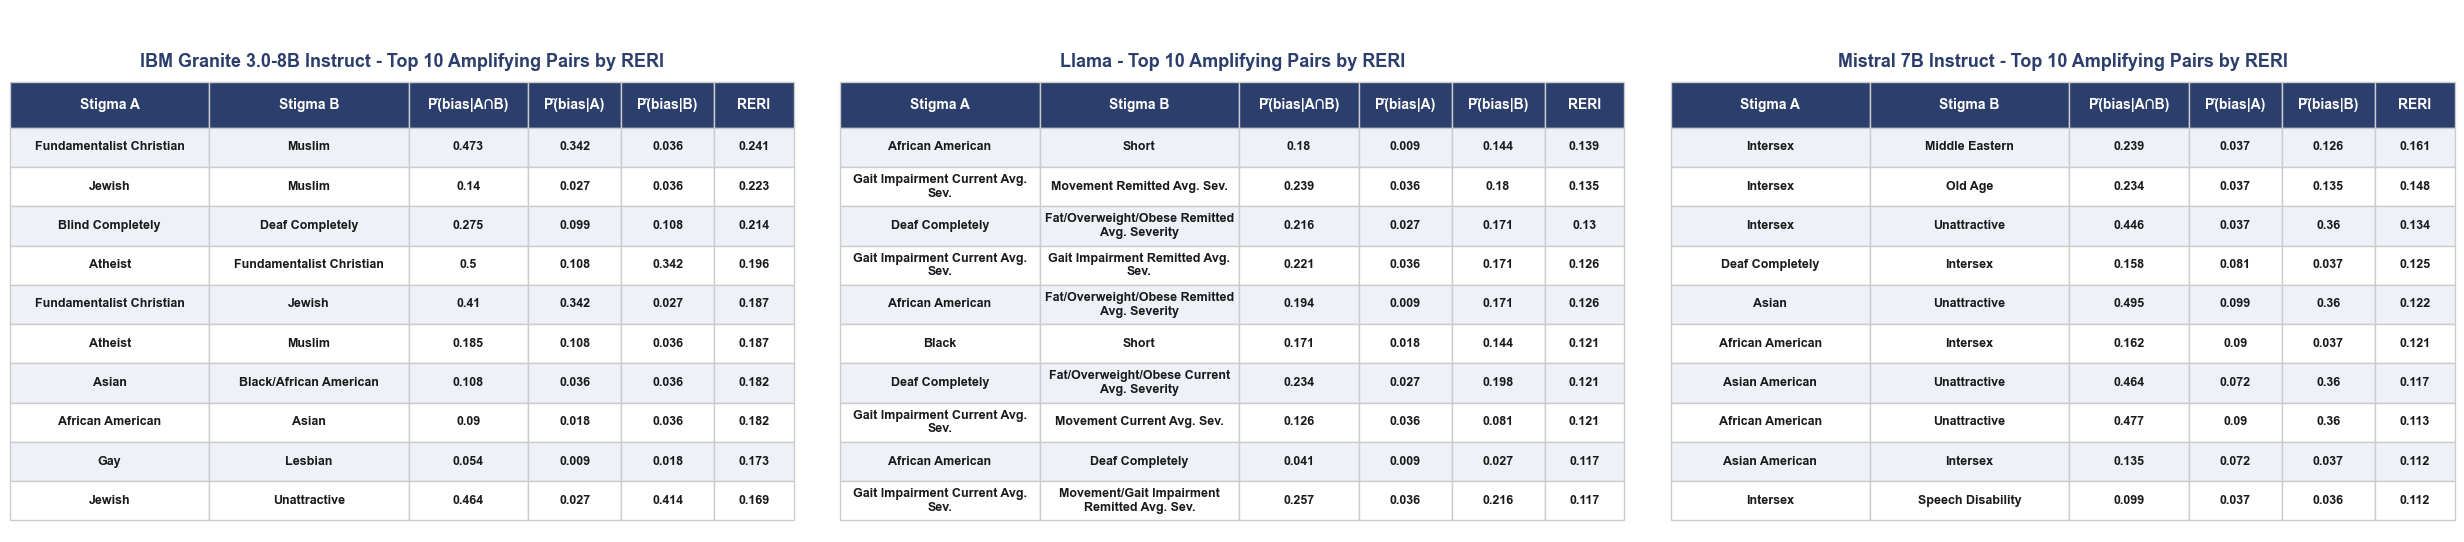

Saved to data/figures/top10_reri.png


In [21]:
MODEL_NAMES = {'granite': 'IBM Granite 3.0-8B Instruct', 'mistral': 'Mistral 7B Instruct'}
import matplotlib.pyplot as plt
import textwrap

def wrap(text, width):
    lines = textwrap.wrap(str(text), width)
    return chr(10).join(lines)

models = list(model_excess.keys())
n_models = len(models)

fig, axes = plt.subplots(1, n_models, figsize=(10 * n_models, 6), facecolor='white')
fig.subplots_adjust(wspace=0.25)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    ib = model_excess[model]['ib'].copy()
    baseline = model_excess[model]['baseline']
    ib['reri'] = ib['combined_bias_rate'] - ib['bias_A'] - ib['bias_B'] + baseline

    top = ib.nlargest(10, 'reri')[[
        'stigma1', 'stigma2', 'combined_bias_rate', 'bias_A', 'bias_B', 'reri'
    ]].round(3).reset_index(drop=True)

    col_labels = ['Stigma A', 'Stigma B', 'P̂(bias|A∩B)', 'P̂(bias|A)', 'P̂(bias|B)', 'RERI']
    col_widths = [0.30, 0.30, 0.18, 0.14, 0.14, 0.12]
    wrap_widths = [32, 32, 14, 10, 10, 9]

    cell_data = [
        [wrap(str(row[c]), w) for c, w in zip(top.columns, wrap_widths)]
        for _, row in top.iterrows()
    ]

    header_color = '#2C3E6B'
    row_colors = ['#EEF1F8', '#FFFFFF']

    ax.axis('off')
    table = ax.table(
        cellText=cell_data,
        colLabels=col_labels,
        cellLoc='center',
        loc='center',
        colWidths=col_widths,
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#cccccc')
        cell.PAD = 0.03
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(color='white', fontweight='bold', fontsize=10)
            cell.set_height(0.10)
        else:
            cell.set_facecolor(row_colors[(row - 1) % 2])
            cell.set_text_props(color='#1a1a1a', fontweight='semibold', fontsize=9)
            cell.set_height(0.085)

    ax.set_title(f'{MODEL_NAMES.get(model, model.capitalize())} - Top 10 Amplifying Pairs by RERI',
                 fontsize=13, fontweight='bold', color='#2C3E6B', pad=2)

plt.suptitle('Top 10 Intersectional Bias Amplifying Pairs  |  RERI = P̂(bias|A∩B) - P̂(bias|A) - P̂(bias|B) + Baseline',
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig(DATA / 'top10_reri.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved to data/figures/top10_reri.png')


# 3. Heat Table

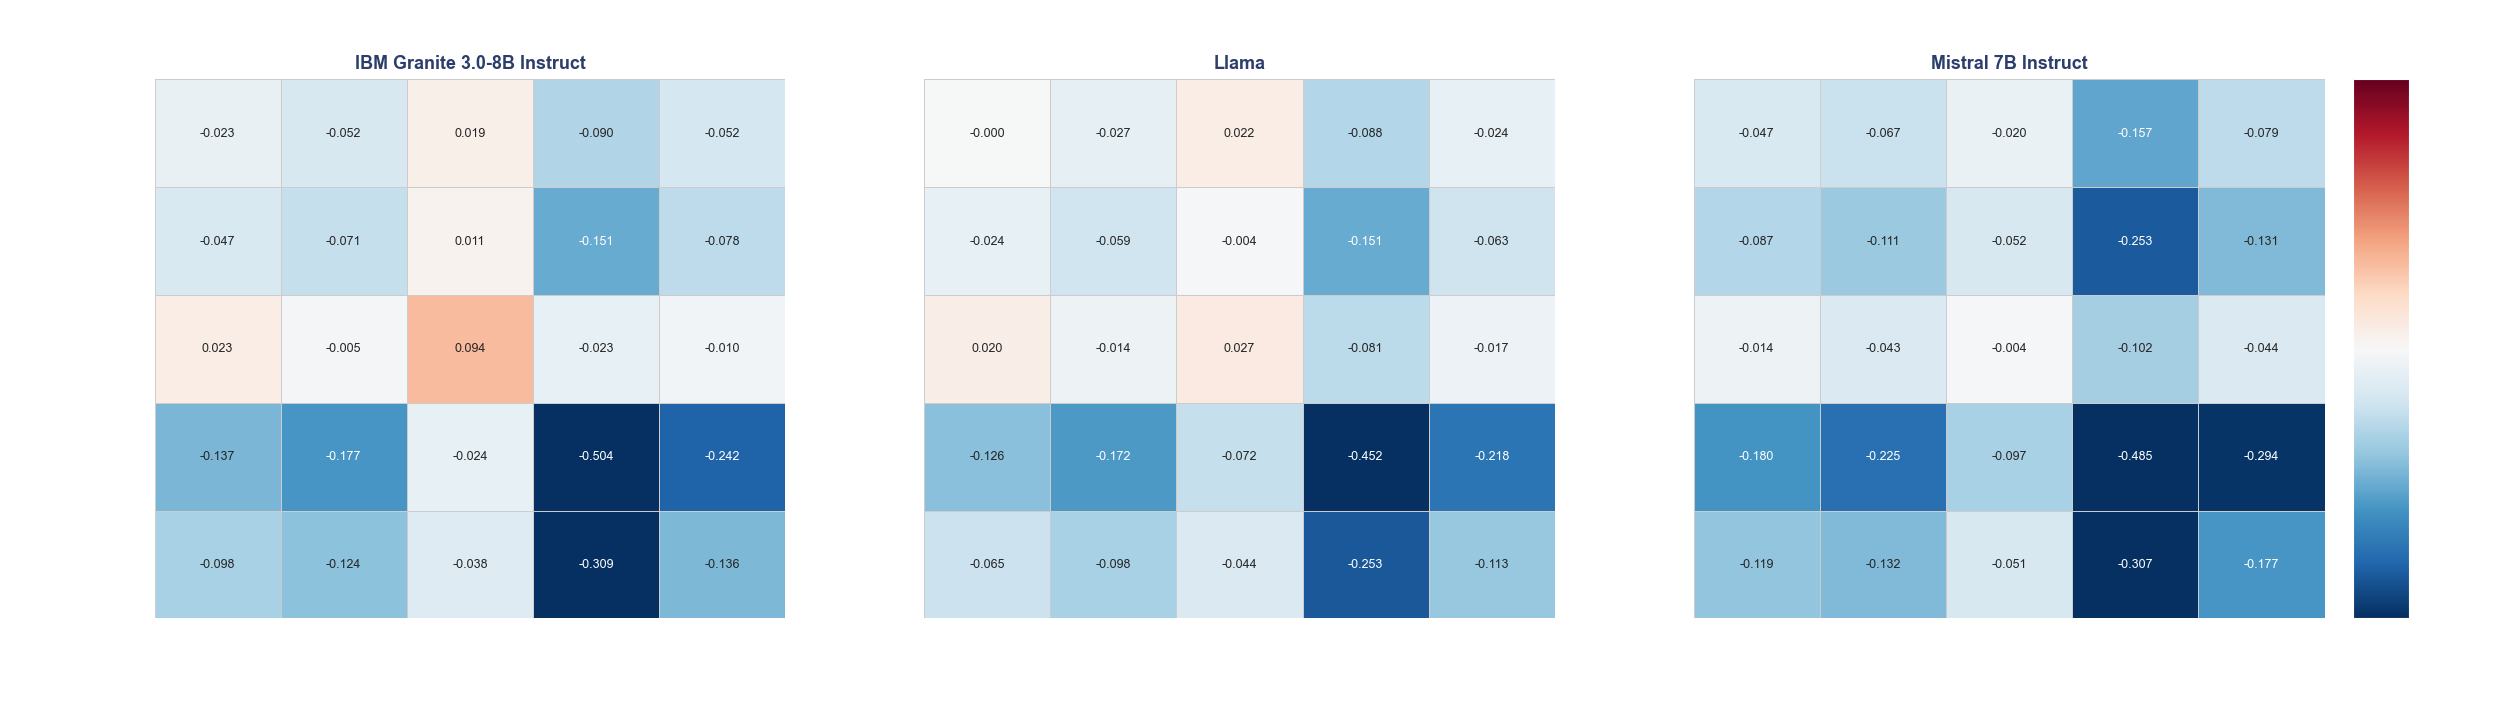

Saved heatmap_clusters_sidebyside.png


In [22]:
MODEL_NAMES = {'granite': 'IBM Granite 3.0-8B Instruct', 'mistral': 'Mistral 7B Instruct'}
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

_neo = pd.read_csv(DATA.parent / 'templates' / 'neostigmas.csv')
cluster_map = _neo.set_index('Stigma')['Cluster'].to_dict()

models = list(model_excess.keys())
n_models = len(models)

fig, axes = plt.subplots(1, n_models, figsize=(9 * n_models + 1, 7), facecolor='white')
fig.subplots_adjust(wspace=0.22)
if n_models == 1:
    axes = [axes]

norm = mcolors.TwoSlopeNorm(vmin=-0.3, vcenter=0, vmax=0.3)

for ax, model in zip(axes, models):
    ib = model_excess[model]['ib'].copy()
    baseline = model_excess[model]['baseline']
    ib['reri'] = ib['combined_bias_rate'] - ib['bias_A'] - ib['bias_B'] + baseline
    ib['cluster_A'] = ib['stigma1'].map(cluster_map).str.replace(r'^\d+ - ', '', regex=True)
    ib['cluster_B'] = ib['stigma2'].map(cluster_map).str.replace(r'^\d+ - ', '', regex=True)
    pivot = ib.groupby(['cluster_A', 'cluster_B'])['reri'].mean().reset_index()
    matrix = pivot.pivot(index='cluster_A', columns='cluster_B', values='reri')
    matrix = matrix.reindex(index=matrix.columns)
    matrix.index.name = None
    matrix.columns.name = None

    sns.heatmap(
        matrix, ax=ax, cmap='RdBu_r', norm=norm,
        annot=True, fmt='.3f', annot_kws={'size': 9},
        linewidths=0.5, linecolor='#cccccc',
        cbar=False,
        xticklabels=True, yticklabels=True
    )
    ax.set_title(f'{MODEL_NAMES.get(model, model.capitalize())}', fontsize=13, fontweight='bold', color='#2C3E6B', pad=8)
    ax.set_xlabel('Cluster B', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cluster A' if ax == axes[0] else '', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

# place colorbar just to the right of the last axis
fig.canvas.draw()
pos = axes[-1].get_position()
cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.02, pos.height])
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_ticks([-0.3, -0.15, 0, 0.15, 0.3])
cbar.set_ticklabels(['-0.3\nsub-additive', '-0.15', '0\nadditive', '0.15', '0.3\nsuper-additive'])
cbar.set_label('Mean RERI', fontsize=10)
cbar.ax.tick_params(labelsize=8)

plt.suptitle('Mean RERI by Cluster Pair\nRERI = P̂(bias|A∩B) − P̂(bias|A) − P̂(bias|B) + Baseline', fontsize=13, fontweight='bold', y=0.98)
plt.savefig(DATA / 'heatmap_clusters_sidebyside.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved heatmap_clusters_sidebyside.png')

In [23]:
from scipy import stats
import numpy as np

_neo = pd.read_csv(DATA.parent / 'templates' / 'neostigmas.csv')
cluster_map = _neo.set_index('Stigma')['Cluster'].to_dict()

# Build mean RERI matrix per model (same 5x5 structure as heatmap)
matrices = {}
for model in model_excess:
    ib = model_excess[model]['ib'].copy()
    baseline = model_excess[model]['baseline']
    ib['reri'] = ib['combined_bias_rate'] - ib['bias_A'] - ib['bias_B'] + baseline
    ib['cluster_A'] = ib['stigma1'].map(cluster_map).str.replace(r'^\d+ - ', '', regex=True)
    ib['cluster_B'] = ib['stigma2'].map(cluster_map).str.replace(r'^\d+ - ', '', regex=True)
    pivot = ib.groupby(['cluster_A', 'cluster_B'])['reri'].mean().reset_index()
    matrix = pivot.pivot(index='cluster_A', columns='cluster_B', values='reri')
    matrix = matrix.reindex(index=matrix.columns)
    matrices[model] = matrix

# Flatten each model's matrix to a vector (same cluster-pair ordering)
ref = list(matrices.values())[0]
pair_labels = [f"{r} × {c}" for r in ref.index for c in ref.columns]
reri_vectors = np.array([matrices[m].values.flatten() for m in matrices])

# Kendall's W
k, n = reri_vectors.shape          # k = models, n = cluster pairs
ranks = np.array([stats.rankdata(v) for v in reri_vectors])
R = ranks.sum(axis=0)              # rank sum per cluster pair
S = np.sum((R - R.mean()) ** 2)
W = 12 * S / (k**2 * (n**3 - n))

chi2_stat = k * (n - 1) * W
p_val = stats.chi2.sf(chi2_stat, df=n - 1)

interp = (
    "very strong" if W >= 0.9 else
    "strong"      if W >= 0.7 else
    "moderate"    if W >= 0.5 else
    "weak"
)

print(f"Kendall's W — concordance across {k} models on {n} cluster pairs")
print(f"  W  = {W:.4f}  ({interp} agreement)")
print(f"  χ² = {chi2_stat:.3f},  df = {n-1},  p = {p_val:.4e}")
print()

rank_df = (pd.DataFrame({'Cluster Pair': pair_labels, 'Rank Sum': R})
             .sort_values('Rank Sum', ascending=False)
             .reset_index(drop=True))
rank_df.index += 1

print("Most consistently amplifying (highest rank sum):")
print(rank_df.head(5).to_string())
print()
print("Most consistently dampening (lowest rank sum):")
print(rank_df.tail(5).sort_values('Rank Sum').to_string())


Kendall's W — concordance across 3 models on 25 cluster pairs
  W  = 0.9708  (very strong agreement)
  χ² = 69.895,  df = 24,  p = 2.2677e-06

Most consistently amplifying (highest rank sum):
                              Cluster Pair  Rank Sum
1      Sociodemographic × Sociodemographic      75.0
2               Sociodemographic × Awkward      71.0
3               Awkward × Sociodemographic      70.0
4  Sociodemographic × Innocuous Persistent      63.0
5  Innocuous Persistent × Sociodemographic      61.0

Most consistently dampening (lowest rank sum):
                            Cluster Pair  Rank Sum
25             Threatening × Threatening       3.0
24  Unappealing Persistent × Threatening       6.0
23  Threatening × Unappealing Persistent       9.0
22    Threatening × Innocuous Persistent      13.0
21    Innocuous Persistent × Threatening      14.0


In [24]:
from scipy import stats
import numpy as np
import pandas as pd

# reri_vectors and pair_labels already computed in the Kendall's W cell above
model_names = list(matrices.keys())

# Pairwise Spearman correlations on raw RERI values
n_models = len(model_names)
rho_mat  = np.ones((n_models, n_models))
pval_mat = np.zeros((n_models, n_models))

for i in range(n_models):
    for j in range(n_models):
        if i != j:
            rho, p = stats.spearmanr(reri_vectors[i], reri_vectors[j])
            rho_mat[i, j]  = rho
            pval_mat[i, j] = p

rho_df  = pd.DataFrame(rho_mat,  index=model_names, columns=model_names).round(4)
pval_df = pd.DataFrame(pval_mat, index=model_names, columns=model_names).round(4)

print("Spearman ρ (raw RERI values across 25 cluster pairs)")
print(rho_df.to_string())
print()
print("p-values")
print(pval_df.to_string())
print()

# Also show mean RERI per model side-by-side so magnitude differences are visible
print("Mean RERI per model (magnitude check):")
for model, vec in zip(model_names, reri_vectors):
    print(f"  {model:10s}  mean={vec.mean():.4f}  min={vec.min():.4f}  max={vec.max():.4f}")


Spearman ρ (raw RERI values across 25 cluster pairs)
         granite   llama  mistral
granite   1.0000  0.9362   0.9646
llama     0.9362  1.0000   0.9677
mistral   0.9646  0.9677   1.0000

p-values
         granite  llama  mistral
granite      0.0    0.0      0.0
llama        0.0    0.0      0.0
mistral      0.0    0.0      0.0

Mean RERI per model (magnitude check):
  granite     mean=-0.0897  min=-0.5036  max=0.0943
  llama       mean=-0.0839  min=-0.4516  max=0.0266
  mistral     mean=-0.1311  min=-0.4854  max=-0.0042


# 4. Scatter Plot

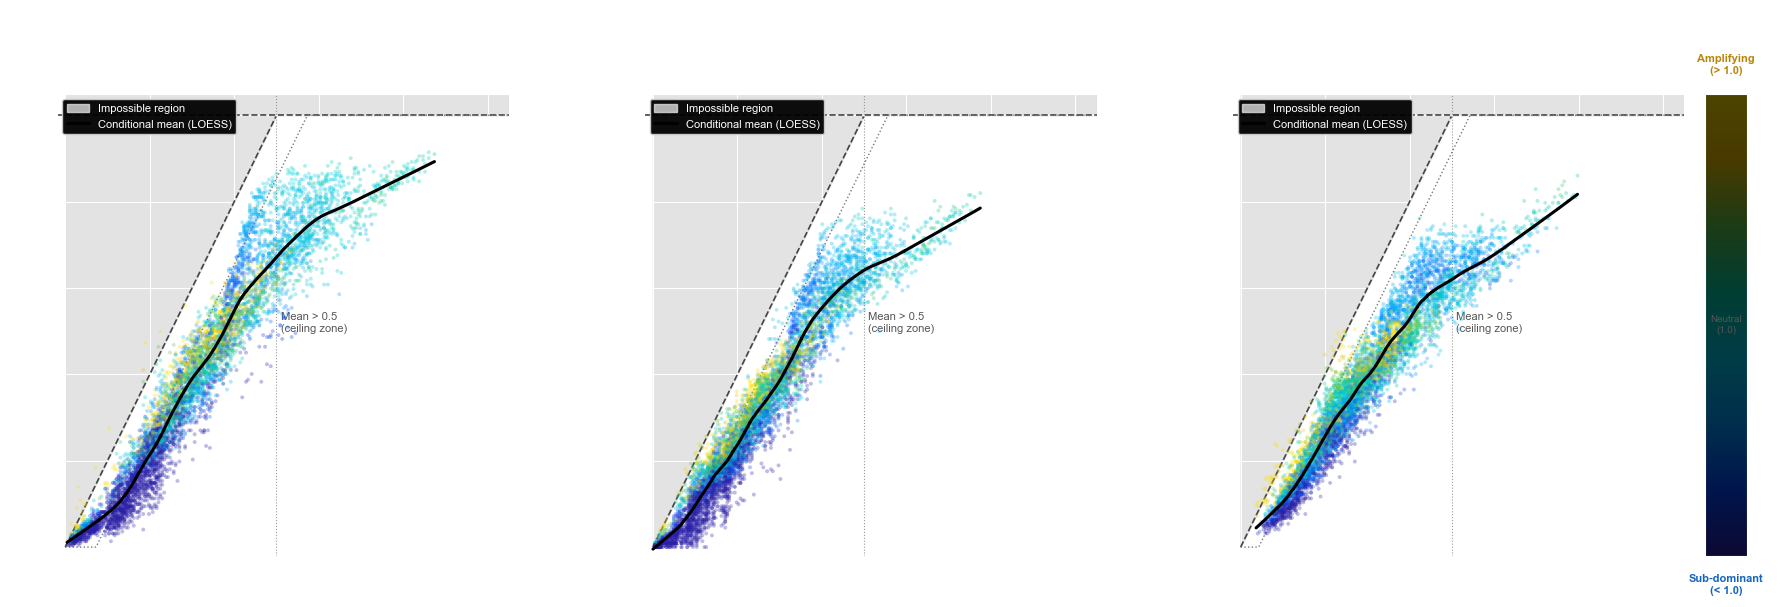

Saved to data/impossible_region_mean.png


In [25]:
MODEL_NAMES = {'granite': 'IBM Granite 3.0-8B Instruct', 'mistral': 'Mistral 7B Instruct'}
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

_parula_colors = [
    '#2A1FA8', '#0047FF', '#0099FF', '#00C8E8',
    '#00CFA8', '#5EC44A', '#F0C000', '#FFE000'
]
cmap_parula = LinearSegmentedColormap.from_list('parula', _parula_colors)
norm = mcolors.TwoSlopeNorm(vmin=0.7, vcenter=1.0, vmax=1.3)

fig, axes = plt.subplots(1, len(model_excess),
                          figsize=(7 * len(model_excess), 6),
                          facecolor='white')
fig.subplots_adjust(wspace=0.3)
if len(model_excess) == 1:
    axes = [axes]

sc_last = None
for ax, (model, s) in zip(axes, model_excess.items()):
    ib = s['ib'].dropna(subset=['bias_A', 'bias_B', 'combined_bias_rate']).copy()
    ib['x'] = (ib['bias_A'] + ib['bias_B']) / 2
    ib['y'] = ib['combined_bias_rate']
    ib['dominance'] = (ib['y'] / ib[['bias_A', 'bias_B']].max(axis=1)).clip(0.7, 1.3)

    x_fill = np.linspace(0, 1.05, 500)
    ax.fill_between(x_fill, np.minimum(2 * x_fill, 1.0), 1.05,
                    color='#DDDDDD', alpha=0.8, zorder=0, label='Impossible region')

    x_left = x_fill[x_fill <= 0.5]
    ax.plot(x_left, 2 * x_left, color='#444444', linewidth=1.2, linestyle='--', zorder=2, )
    ax.axhline(1.0, color='#444444', linewidth=1.2, linestyle='--', zorder=2)
    ax.axvline(0.5, color='#999999', linewidth=0.8, linestyle=':', zorder=2)
    ax.text(0.51, 0.52, 'Mean > 0.5\n(ceiling zone)', fontsize=8, color='#555555', va='center', ha='left')

    baseline_val = s['baseline']
    x_ref = np.linspace(0, 1.05, 500)
    y_ref = np.clip(2 * x_ref - baseline_val, 0, 1)
    ax.plot(x_ref, y_ref, color='#777777', linewidth=1.0, linestyle=':', zorder=3, )

    sc = ax.scatter(ib['x'], ib['y'], c=ib['dominance'], cmap=cmap_parula, norm=norm,
                    alpha=0.30, s=8, linewidths=0, zorder=3)
    sc_last = sc

    smooth = lowess(ib['y'].values, ib['x'].values, frac=0.15, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], color='black', linewidth=2.2, zorder=5, label='Conditional mean (LOESS)')

    ax.set_xlabel('[P(bias|A) + P(bias|B)] / 2  [mean individual bias]', fontsize=10)
    ax.set_ylabel('P(bias|A∩B)  [observed joint bias]', fontsize=10)
    ax.set_title(MODEL_NAMES.get(model, model.capitalize()), fontsize=12, fontweight='bold', pad=6)
    ax.set_xlim(-0.02, 1.05)
    ax.set_ylim(-0.02, 1.05)
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=8, loc='upper left', framealpha=0.95)
    ax.set_facecolor('white')

# single shared colorbar
fig.canvas.draw()
pos = axes[-1].get_position()
cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.02, pos.height])
cbar = fig.colorbar(sc_last, cax=cax)
cbar.set_ticks([])
cbar.set_label('Dominance ratio\nP̂(bias|A∩B) / max(P̂(bias|A), P̂(bias|B))', fontsize=8, labelpad=8)
cbar.ax.axhline(0.5, color='black', linewidth=1.0, linestyle='--')
cbar.ax.text(0.5, 1.04, 'Amplifying\n(> 1.0)', ha='center', va='bottom',
             fontsize=8, fontweight='bold', color='#B8860B', transform=cbar.ax.transAxes)
cbar.ax.text(0.5, 0.5, 'Neutral\n(1.0)', ha='center', va='center',
             fontsize=7, color='#555555', transform=cbar.ax.transAxes)
cbar.ax.text(0.5, -0.04, 'Sub-dominant\n(< 1.0)', ha='center', va='top',
             fontsize=8, fontweight='bold', color='#1565C0', transform=cbar.ax.transAxes)

plt.suptitle('Observed vs. mean individual bias across identity pairs.',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig(DATA / 'impossible_region_mean.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved to data/impossible_region_mean.png')


In [29]:
import numpy as np
import pandas as pd

# reri_vectors and model_names already available from prior cells

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

n_models = len(model_names)
cos_mat = np.ones((n_models, n_models))

for i in range(n_models):
    for j in range(n_models):
        if i != j:
            cos_mat[i, j] = cosine_sim(reri_vectors[i], reri_vectors[j])

cos_df = pd.DataFrame(cos_mat, index=model_names, columns=model_names).round(4)

print("Cosine Similarity (raw RERI vectors, 25 cluster pairs)")
print(cos_df.to_string())


Cosine Similarity (raw RERI vectors, 25 cluster pairs)
         granite   llama  mistral
granite   1.0000  0.9849   0.9594
llama     0.9849  1.0000   0.9734
mistral   0.9594  0.9734   1.0000


In [31]:
from scipy import stats
import numpy as np

print("Order Sensitivity of Stigma Pairs")
print("Does (A, B) produce different bias than (B, A)?")
print("=" * 55)

for csv_path in sorted(DATA.glob('results__*__with_single__*.csv')):
    raw = pd.read_csv(csv_path)
    raw['biased'] = (raw['model_answer'] == raw['biased_answer']).astype(int)
    model_name = raw['model'].iloc[0]

    pairs = raw[
        (raw['stigma2'].notna()) &
        (raw['prompt_style'] != 'base') &
        (raw['model_answer'].isin(['yes', 'no']))
    ]

    bias = pairs.groupby(['stigma1', 'stigma2'])['biased'].mean().reset_index()
    bias.columns = ['stigma1', 'stigma2', 'bias_rate']

    forward = bias.copy()
    reverse = bias.rename(columns={'stigma1': 'stigma2', 'stigma2': 'stigma1',
                                   'bias_rate': 'bias_rate_rev'})
    merged = forward.merge(reverse, on=['stigma1', 'stigma2'])
    merged['diff']     = merged['bias_rate'] - merged['bias_rate_rev']
    merged['abs_diff'] = merged['diff'].abs()

    t, p = stats.ttest_rel(merged['bias_rate'], merged['bias_rate_rev'])
    r = merged['bias_rate'].corr(merged['bias_rate_rev'])

    print(f"\n{model_name}  ({len(merged):,} ordered pairs)")
    print(f"  Mean |diff|       : {merged['abs_diff'].mean():.4f}")
    print(f"  Max  |diff|       : {merged['abs_diff'].max():.4f}")
    print(f"  Correlation r     : {r:.4f}")
    print(f"  Paired t-test     : t={t:.3f}, p={p:.4f}")

    top = (merged
           .nlargest(5, 'abs_diff')
           [['stigma1', 'stigma2', 'bias_rate', 'bias_rate_rev', 'diff']]
           .rename(columns={'bias_rate': 'bias(A,B)', 'bias_rate_rev': 'bias(B,A)'}))
    print(f"\n  Most order-sensitive pairs:")
    print(top.to_string(index=False))

print()
print("Conclusion: averaging both orderings (as in compute_excess) is justified globally,")
print("but individual pairs can differ by up to ~0.32 depending on which stigma leads.")


Order Sensitivity of Stigma Pairs
Does (A, B) produce different bias than (B, A)?

granite  (12,432 ordered pairs)
  Mean |diff|       : 0.0489
  Max  |diff|       : 0.3243
  Correlation r     : 0.9624
  Paired t-test     : t=-0.000, p=1.0000

  Most order-sensitive pairs:
                    stigma1                     stigma2  bias(A,B)  bias(B,A)      diff
Alcohol Dependency Remitted                 South Asian   0.306306   0.630631 -0.324324
                South Asian Alcohol Dependency Remitted   0.630631   0.306306  0.324324
   Drug Dependency Remitted                 South Asian   0.342342   0.666667 -0.324324
                South Asian    Drug Dependency Remitted   0.666667   0.342342  0.324324
   Drug Dependency Remitted                      Latina   0.270270   0.576577 -0.306306

llama  (12,432 ordered pairs)
  Mean |diff|       : 0.0302
  Max  |diff|       : 0.2613
  Correlation r     : 0.9792
  Paired t-test     : t=-0.000, p=1.0000

  Most order-sensitive pairs:
        

In [32]:
from scipy import stats
import numpy as np

_neo = pd.read_csv(DATA.parent / 'templates' / 'neostigmas.csv')
cluster_map = _neo.set_index('Stigma')['Cluster'].str.replace(r'^\d+ - ', '', regex=True).to_dict()

SUBSTANCE_CLUSTER  = 'Unappealing Persistent'
RACE_CLUSTER       = 'Sociodemographic'

results_by_model = {}

for csv_path in sorted(DATA.glob('results__*__with_single__*.csv')):
    raw = pd.read_csv(csv_path)
    raw['biased'] = (raw['model_answer'] == raw['biased_answer']).astype(int)
    model_name = raw['model'].iloc[0]

    pairs = raw[
        (raw['stigma2'].notna()) &
        (raw['prompt_style'] != 'base') &
        (raw['model_answer'].isin(['yes', 'no']))
    ]

    grouped = pairs.groupby(['stigma1', 'stigma2'])['biased'].apply(list).reset_index()
    grouped.columns = ['stigma1', 'stigma2', 'responses']
    forward = grouped.set_index(['stigma1', 'stigma2'])

    results = []
    for _, row in grouped.iterrows():
        a, b = row['stigma1'], row['stigma2']
        if a > b or (b, a) not in forward.index:
            continue
        r_ab = row['responses']
        r_ba = forward.loc[(b, a), 'responses']
        n_ab, s_ab = len(r_ab), sum(r_ab)
        n_ba, s_ba = len(r_ba), sum(r_ba)
        table = [[s_ab, n_ab - s_ab], [s_ba, n_ba - s_ba]]
        try:
            _, p, _, _ = stats.chi2_contingency(table)
        except ValueError:
            p = 1.0
        results.append({'stigma1': a, 'stigma2': b,
                        'bias_AB': round(s_ab/n_ab, 4),
                        'bias_BA': round(s_ba/n_ba, 4),
                        'abs_diff': round(abs(s_ab/n_ab - s_ba/n_ba), 4),
                        'p': p})

    res = pd.DataFrame(results).sort_values('p').reset_index(drop=True)
    n = len(res)
    res['rank'] = res.index + 1
    res['p_fdr'] = (res['p'] * n / res['rank']).clip(upper=1.0)
    res['p_fdr'] = res['p_fdr'][::-1].cummin()[::-1]
    results_by_model[model_name] = res

# ── Report ────────────────────────────────────────────────────────────────────
print("Order Effect Significance — Chi-squared per pair, BH FDR correction")
print("=" * 65)

for model_name, res in results_by_model.items():
    sig = res[res['p_fdr'] < 0.05].copy()
    total = len(res)
    print(f"\n{model_name}: {len(sig)} / {total:,} pairs significant (q < 0.05)  "
          f"({100*len(sig)/total:.1f}%)")

    if len(sig) == 0:
        print("  No significant order effects.")
        continue

    # Assign clusters
    sig['cluster_A'] = sig['stigma1'].map(cluster_map).fillna('unknown')
    sig['cluster_B'] = sig['stigma2'].map(cluster_map).fillna('unknown')

    # Check if all involve substance x race
    is_substance_race = sig.apply(
        lambda r: set([r.cluster_A, r.cluster_B]) == {SUBSTANCE_CLUSTER, RACE_CLUSTER}, axis=1
    )
    print(f"  Involve {SUBSTANCE_CLUSTER} x {RACE_CLUSTER}: "
          f"{is_substance_race.sum()} / {len(sig)}  "
          f"({'ALL' if is_substance_race.all() else 'NOT ALL'})")

    print(f"\n  Cluster breakdown of significant pairs:")
    print(sig.groupby(['cluster_A', 'cluster_B']).size()
            .reset_index(name='n_pairs').to_string(index=False))

    print(f"\n  All {len(sig)} significant pairs (q < 0.05):")
    display_cols = ['stigma1', 'stigma2', 'bias_AB', 'bias_BA', 'abs_diff', 'p_fdr']
    print(sig[display_cols].to_string(index=False))


Order Effect Significance — Chi-squared per pair, BH FDR correction

granite: 24 / 6,216 pairs significant (q < 0.05)  (0.4%)
  Involve Unappealing Persistent x Sociodemographic: 15 / 24  (NOT ALL)

  Cluster breakdown of significant pairs:
             cluster_A              cluster_B  n_pairs
  Innocuous Persistent   Innocuous Persistent        1
  Innocuous Persistent       Sociodemographic        1
  Innocuous Persistent Unappealing Persistent        2
      Sociodemographic   Innocuous Persistent        1
      Sociodemographic Unappealing Persistent        5
Unappealing Persistent   Innocuous Persistent        3
Unappealing Persistent       Sociodemographic       10
Unappealing Persistent Unappealing Persistent        1

  All 24 significant pairs (q < 0.05):
                    stigma1                       stigma2  bias_AB  bias_BA  abs_diff    p_fdr
Alcohol Dependency Remitted                   South Asian   0.3063   0.6306    0.3243 0.008154
   Drug Dependency Remitted       